# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

A possible Who, What, and How for my health disparities data includes:
- Who: Those interested in exploring the health disparities that exist in underserved communities, low-income populations, and racial / ethnic minorities
- What: Shedding light on the lack of access to healthcare, lower quality of care, and negative health outcomes
- How: By highlighting the health disparities that exist amongst different populations within the United States, through data.

# 3. Homework - work with your own data

In [72]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA):

# NCHS dataset
nchs = pd.read_csv('https://data.cdc.gov/api/views/w9j2-ggv5/rows.csv?accessType=DOWNLOAD', sep=',')
print(nchs.head(5))

# Dataset summary
print(nchs.info())
print(nchs.describe())

# Search for duplicate values
nchs_duplicates = nchs.duplicated().sum()
print(f'\nThe number of duplicate rows in the dataset is: {nchs_duplicates}')

# Mean, median, and mode of each column
num = nchs.select_dtypes(include=[np.number])
nchs_mean = num.mean()
nchs_median = num.median()
nchs_mode = num.mode().iloc[0]  # first mode if multiple modes exist

print(f'\nMean of each column: \n{nchs_mean}')
print(f'\nMedian of each column: \n{nchs_median}')
print(f'\nMode of each column: \n{nchs_mode}')

# Search for missing or null values
nchs_null = nchs.isnull().sum()
print(f'\nMissing values in each column before cleaning: \n{nchs_null}')

# Remove rows with missing values
nchs_clean = nchs.dropna()
print(f'\nMissing values in each column after cleaning: \n{nchs_clean.isnull().sum()}')

# Encode any categorical variables
from sklearn.preprocessing import OneHotEncoder

categorical_features = nchs_clean.select_dtypes(exclude=['number']).columns.tolist()    # To get list of categorical features
print(f'\nCategorical features: {categorical_features}')

one_hot_encoded = pd.get_dummies(nchs_clean[['Race', 'Sex']])
nchs_encoded = nchs_clean.join(one_hot_encoded, rsuffix='_encoded')
print(nchs_encoded.head(5))

   Year       Race         Sex  Average Life Expectancy (Years)  \
0  1900  All Races  Both Sexes                             47.3   
1  1901  All Races  Both Sexes                             49.1   
2  1902  All Races  Both Sexes                             51.5   
3  1903  All Races  Both Sexes                             50.5   
4  1904  All Races  Both Sexes                             47.6   

   Age-adjusted Death Rate  
0                   2518.0  
1                   2473.1  
2                   2301.3  
3                   2379.0  
4                   2502.5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             1071 non-null   int64  
 1   Race                             1071 non-null   object 
 2   Sex                              1071 non-null   object 
 3   Av

CONCLUSIONS: 
- The dataset contains several columns with missing values, which were handled by dropping rows with null values. No class imbalances were found.
- Categorical variables were encoded using one-hot encoding.
- The cleaned and encoded dataset is now ready for further analysis.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

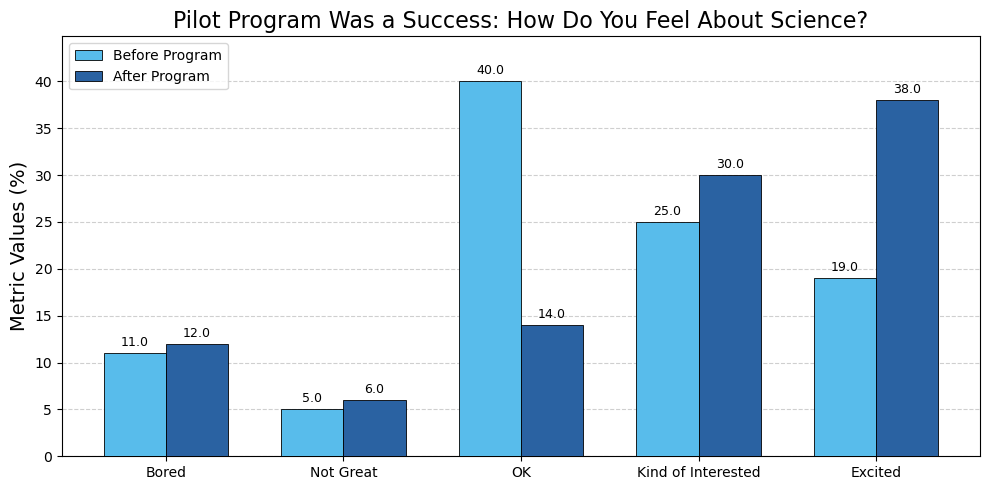

In [74]:
# STORYTELLING WITH DATA GRAPH:

# Pilot Program bar chart
import matplotlib.pyplot as plt
import seaborn as sns
                    
metrics = ["Bored","Not Great","OK","Kind of Interested", "Excited"]
before_program = [11, 5, 40, 25, 19]
after_program = [12, 6, 14, 30, 38]

x = np.arange(len(metrics))
width = 0.35
palette = sns.color_palette(["#58bceb","#2a62a2"])

fig, ax = plt.subplots(figsize=(10,5))
bars1 = ax.bar(x - width/2, before_program, width, label='Before Program',
               color=palette[0], edgecolor='k', linewidth=0.6, zorder=3)
bars2 = ax.bar(x + width/2, after_program, width, label='After Program',
               color=palette[1], edgecolor='k', linewidth=0.6, zorder=3)

# Annotate values (use ax.bar_label if matplotlib >= 3.4)
ax.bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)

# Axes, grid, legend
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=0, fontsize=10)
ax.set_ylabel('Metric Values (%)', fontsize=14)
ax.set_title('Pilot Program Was a Success: How Do You Feel About Science?', fontsize=16)
ax.legend(frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Give vertical breathing room so labels don't collide with bar tops
top = max(before_program + after_program)
ax.set_ylim(0, top * 1.12)

plt.tight_layout()
plt.show()